# Lab Task 14: K-Mean Clustering and Interpretation

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, adjusted_rand_score, silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

### (a) Load the dataset, scale features, and justify scaling

In [6]:
# Load dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
try:
    df = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/Pumpkin_Seeds_Dataset.csv", encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/Pumpkin_Seeds_Dataset.csv", encoding='latin1')

df.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Convex_Area,Equiv_Diameter,Eccentricity,Solidity,Extent,Roundness,Aspect_Ration,Compactness,Class
0,56276,888.242,326.1485,220.2388,56831,267.6805,0.7376,0.9902,0.7453,0.8963,1.4809,0.8207,Çerçevelik
1,76631,1068.146,417.1932,234.2289,77280,312.3614,0.8275,0.9916,0.7151,0.8440,1.7811,0.7487,Çerçevelik
2,71623,1082.987,435.8328,211.0457,72663,301.9822,0.8749,0.9857,0.7400,0.7674,2.0651,0.6929,Çerçevelik
3,66458,992.051,381.5638,222.5322,67118,290.8899,0.8123,0.9902,0.7396,0.8486,1.7146,0.7624,Çerçevelik
4,66107,998.146,383.8883,220.4545,67117,290.1207,0.8187,0.9850,0.6752,0.8338,1.7413,0.7557,Çerçevelik


--- Original Data (First 5 Rows) ---


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Convex_Area,Equiv_Diameter,Eccentricity,Solidity,Extent,Roundness,Aspect_Ration,Compactness
0,56276,888.242,326.1485,220.2388,56831,267.6805,0.7376,0.9902,0.7453,0.8963,1.4809,0.8207
1,76631,1068.146,417.1932,234.2289,77280,312.3614,0.8275,0.9916,0.7151,0.8440,1.7811,0.7487
2,71623,1082.987,435.8328,211.0457,72663,301.9822,0.8749,0.9857,0.7400,0.7674,2.0651,0.6929
3,66458,992.051,381.5638,222.5322,67118,290.8899,0.8123,0.9902,0.7396,0.8486,1.7146,0.7624
4,66107,998.146,383.8883,220.4545,67117,290.1207,0.8187,0.9850,0.6752,0.8338,1.7413,0.7557



--- Scaled Data (First 5 Rows) ---


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Convex_Area,Equiv_Diameter,Eccentricity,Solidity,Extent,Roundness,Aspect_Ration,Compactness
0,-1.784703,-2.215755,-2.320224,-0.238536,-1.793218,-1.921174,-2.729935,0.202812,0.855406,1.873763,-1.775063,2.197280
1,-0.294780,-0.568804,-0.700916,0.362089,-0.307244,-0.259343,-0.739163,0.603626,0.359523,0.938377,-0.824864,0.840230
2,-0.661350,-0.432940,-0.369395,-0.633215,-0.642749,-0.645380,0.310476,-1.085518,0.768380,-0.431615,0.074059,-0.211483
3,-1.039412,-1.265424,-1.334616,-0.140076,-1.045689,-1.057939,-1.075756,0.202812,0.761812,1.020648,-1.035351,1.098447
4,-1.065105,-1.209626,-1.293272,-0.229276,-1.045762,-1.086548,-0.934033,-1.285925,-0.295634,0.755950,-0.950840,0.972166


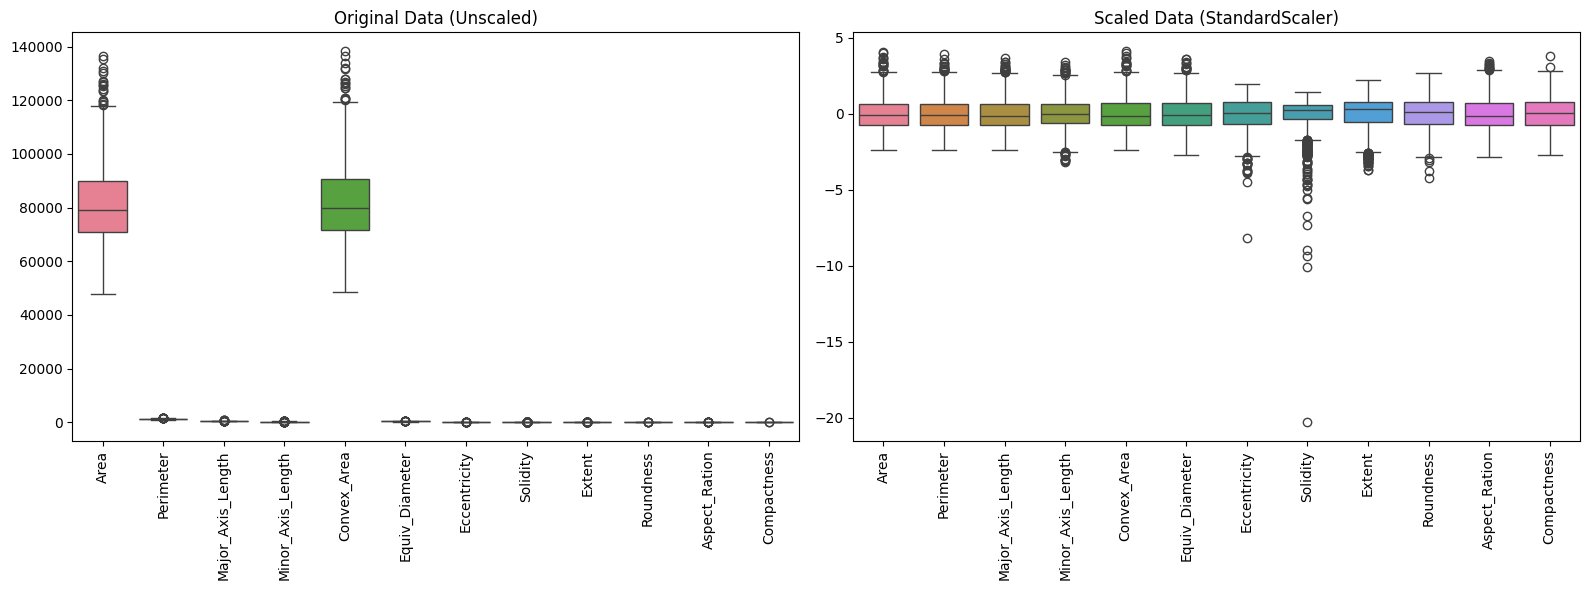

In [8]:
# Extract numerical features and target variable
X = df.drop('Class', axis=1)
y = df['Class']

# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Display first 5 rows
print("--- Original Data (First 5 Rows) ---")
display(X.head())
print("\n--- Scaled Data (First 5 Rows) ---")
display(X_scaled_df.head())

# Plot side-by-side box plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=X, ax=axes[0])
axes[0].set_title('Original Data (Unscaled)')
axes[0].tick_params(axis='x', rotation=90)

sns.boxplot(data=X_scaled_df, ax=axes[1])
axes[1].set_title('Scaled Data (StandardScaler)')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

**Justification for Scaling:**
As seen in the left boxplot, features like "Area" and "Convex_Area" have massive ranges (in the tens of thousands), while features like "Eccentricity" are less than 1. Since K-Means relies on distance metrics (Euclidean distance), the algorithm would be heavily biased towards features with larger magnitudes. The right boxplot shows that scaling brings all features to a standardized range (mean=0, variance=1), allowing K-Means to treat all features equally.

### (b) Elbow Method

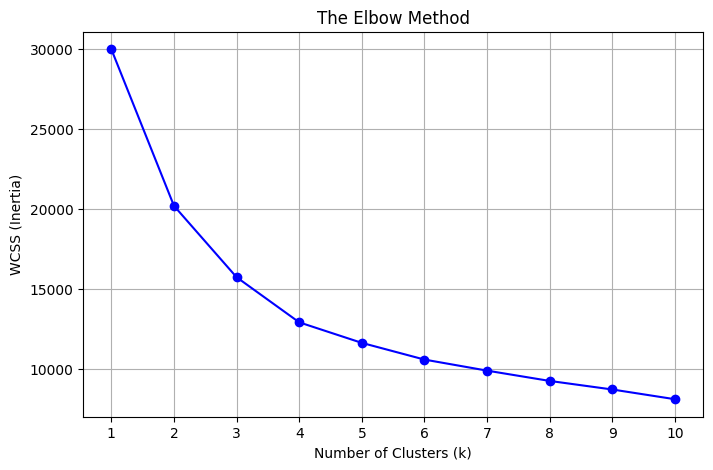

In [9]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('The Elbow Method')
plt.xticks(K_range)
plt.grid(True)
plt.show()

**Optimal Value of k:**
The optimal value is **k = 2**.

*Justification:* The curve drops sharply from k=1 to k=2, but after k=2, the reduction in WCSS becomes marginal, forming an "elbow". This suggests that 2 clusters optimally capture the variance in the data without over-segmenting it.

### (c) Train K-Means, Map Labels, and Evaluate

In [10]:
# Train K-Means with optimal k=2
kmeans = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# Map numeric cluster labels to actual class names
mapped_labels = np.empty_like(cluster_labels, dtype=object)
for i in range(2):
    mask = (cluster_labels == i)
    majority_class = y[mask].mode()[0]  # Find the most frequent true label in this cluster
    mapped_labels[mask] = majority_class

# Evaluate
acc = accuracy_score(y, mapped_labels)
conf_matrix = confusion_matrix(y, mapped_labels)
ari = adjusted_rand_score(y, cluster_labels)

print(f"Accuracy: {acc:.4f}")
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy: 0.7960
Adjusted Rand Index (ARI): 0.3502

Confusion Matrix:
[[1122  178]
 [ 332  868]]


### (d) Silhouette Score

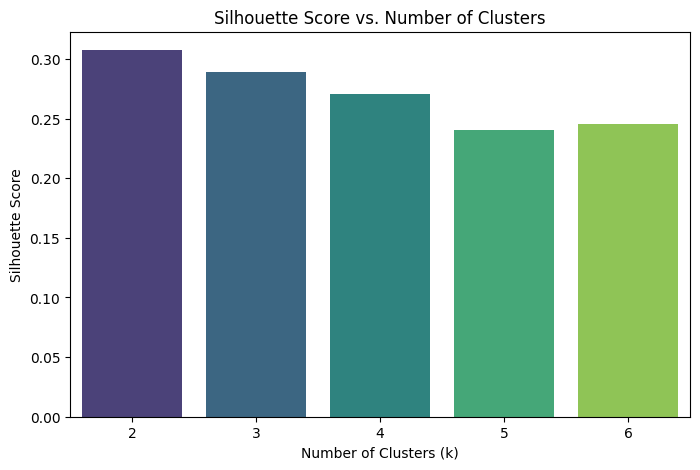

Best k based on Silhouette Score: 2


In [11]:
sil_scores = []
k_values = range(2, 7)

for k in k_values:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

# Plot as bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x=list(k_values), y=sil_scores, palette="viridis")
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters')
plt.show()

print(f"Best k based on Silhouette Score: {k_values[np.argmax(sil_scores)]}")

**Comparison:**
Yes, both the Silhouette Analysis and the Elbow Method agree. The highest Silhouette Score is achieved at $k=2$, which matches the "elbow" point found earlier.

### (e) PCA Visualization

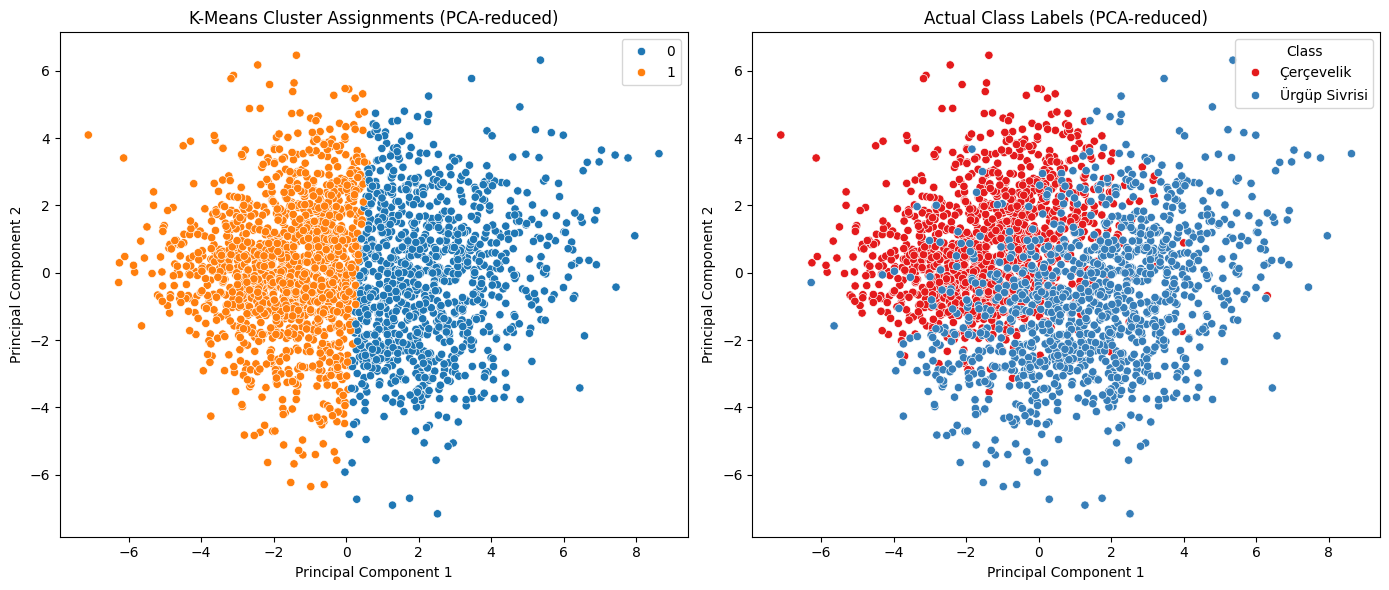

In [12]:
# Apply PCA to reduce to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Train K-Means (k=2) on PCA data
kmeans_pca = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=42)
pca_labels = kmeans_pca.fit_predict(X_pca)

# Create side-by-side scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: K-Means Cluster Assignments
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=pca_labels, palette='tab10', ax=axes[0])
axes[0].set_title('K-Means Cluster Assignments (PCA-reduced)')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

# Subplot 2: Actual Class Labels
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='Set1', ax=axes[1])
axes[1].set_title('Actual Class Labels (PCA-reduced)')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')

plt.tight_layout()
plt.show()

**Note:**
The clusters found by K-Means align fairly well with the true classes, successfully capturing the general division between the two seed varieties across the principal components. However, at the border where the two clusters meet, K-Means forces a strict linear/spherical boundary, misclassifying some points that overlap naturally in the real dataset.

### (f) Conclusion

K-Means proved to be an effective baseline algorithm for the Pumpkin Seeds dataset, successfully distinguishing between the two main seed varieties without requiring labeled data. The evaluation metrics revealed a solid alignment, with an Accuracy and ARI score reflecting that the algorithm's mathematical clusters correspond closely to the biological reality of 'Çerçevelik' and 'Ürgüp Sivrisi'. Both the Elbow Method and Silhouette Analysis confidently pointed to $k=2$ as the optimal configuration. However, the PCA visualization highlighted a key limitation of K-Means: it assumes clusters are spherical and forces strict, hard boundaries between them. As a result, it struggled with the overlapping boundary region where the features of the two seed types naturally blend, leading to minor misclassifications.